# GKP State Preparation via GRAPE

Optimal control synthesis of a pulse that prepares a finite-energy GKP $\ket{0_L}$ state from vacuum in a single Kerr-nonlinear cavity driven by two-photon (squeezing) controls. The optimization uses gradient ascent in the Fourier domain with soft Lagrange-multiplier penalties enforcing amplitude limits, smoothness, and zero-amplitude boundaries.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import jaxquantum as jqt

from gkp_optimal_control.grape import (
    System,
    TimeGrid,
    FourierBand,
    Penalties,
    run_grape,
    save_pulse,
    forward_evolve_history,
)
from gkp_optimal_control.hamiltonians import (
    kerr_cavity_drift,
    kerr_cavity_squeezing_controls,
    cavity_displacement_controls,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import gkp_states
from gkp_optimal_control.utils import wigner_trajectory
from gkp_optimal_control.animation import animate_wigner

set_plot_style()

## Target state

The target is the finite-energy logical $\ket{0_L}$ for a square-lattice GKP code with primitive displacements $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$. The envelope width $\Delta$ sets the effective squeezing; the Fock-space truncation must accommodate the full support of the state.

In [2]:
n_fock = 80
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = jnp.sqrt(np.pi / 2)
gkp_beta = jnp.sqrt(np.pi / 2) * 1j

vac = jqt.basis(n_fock, 0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)

psi_init = jnp.asarray(gkp_0.data.reshape(-1), dtype=jnp.complex128)
psi_targ = jnp.asarray(gkp_1.data.reshape(-1), dtype=jnp.complex128)

tail_population = float(jnp.sum(jnp.abs(psi_targ[-10:]) ** 2))
print(f"Target tail population (top 10 Fock levels): {tail_population:.2e}")

Target tail population (top 10 Fock levels): 4.72e-06


## System Hamiltonian

Single Kerr-nonlinear cavity in the rotating frame:
$$H/\hbar = \frac{K}{2} \hat{a}^\dagger \hat{a}^\dagger \hat{a} \hat{a} + \epsilon_I(t)\,(a^2 + a^{\dagger 2}) + i\,\epsilon_Q(t)\,(a^2 - a^{\dagger 2}).$$

The two control fields are the in-phase and quadrature components of a two-photon (squeezing) drive. Frequencies are stored as angular rates ($2\pi \times \text{MHz} = \text{rad}/\mu s$) and times in microseconds.

In [6]:
K = 2 * jnp.pi * (-0.05)  # Kerr nonlinearity, rad/μs

h_drift = kerr_cavity_drift(n_fock, kerr=K)
h_squeeze = kerr_cavity_squeezing_controls(n_fock)  # 2 controls (a², a†²)
# h_displace   = cavity_displacement_controls(n_fock)        # 2 controls (a, a†)
# h_controls   = jnp.concatenate([h_squeeze, h_displace])    # (4, dim, dim)

system = System(
    H_drift=h_drift,
    H_controls=h_squeeze,
    psi_init=psi_init,
    psi_targ=psi_targ,
)

## Optimization configuration

The pulse is parametrized in the Fourier domain with a hard frequency cutoff at $f_{\max}$. Soft penalties enforce amplitude limit $\epsilon_{\max}$, smoothness (squared-derivative), and zero amplitude in the first/last `boundary_n_zero` samples.

In [18]:
time_grid = TimeGrid(T=1.0, n_steps=500)  # 1.0 μs total, dt = 2 ns

band = FourierBand(f_max=50.0)  # MHz

penalties = Penalties(
    amp=1.0,
    deriv=1e-3,
    boundary=1.0,
    eps_max=5.0,
    boundary_n_zero=3,
)

## Run GRAPE

L-BFGS-B with analytic gradients via JAX autodiff. The first call pays a one-time JIT compilation cost; subsequent calls reuse the compiled cost-and-gradient function.

In [19]:
result, diag, params_to_pulse = run_grape(
    system,
    time_grid,
    band,
    penalties,
    seed=0,
    init_scale=0.001,
    maxiter=200,
)

 iter          loss         F      |grad|   elapsed
-------------------------------------------------------
   10     -0.217928   0.21851   6.501e-01     22.3s
   20     -0.353076   0.36196   2.126e+00     37.1s
   30     -0.468672   0.47081   5.512e-01     50.3s
   40     -0.564130   0.57050   1.799e+00     68.3s
   50     -0.647348   0.65442   1.263e+00     82.2s
   60     -0.695045   0.70503   2.053e+00    101.9s
   70     -0.719571   0.72613   1.288e+00    125.9s
   80     -0.761172   0.76663   6.639e-01    146.6s
   90     -0.773713   0.77869   2.649e-01    161.4s
  100     -0.780031   0.78469   5.877e-01    175.2s
  110     -0.788647   0.79386   8.834e-01    191.0s
  120     -0.792001   0.79652   1.276e-01    206.9s
  130     -0.792710   0.79692   3.567e-01    224.5s
  140     -0.793792   0.79762   3.025e-01    241.9s
  150     -0.795151   0.79859   1.211e-01    257.6s
  160     -0.796192   0.79958   1.114e-01    271.7s
  170     -0.796915   0.80010   2.372e-01    287.3s
  180   

## Optimized pulse waveforms

Time-domain in-phase (I) and quadrature (Q) components of the two-photon drive, with the amplitude bound shown as a horizontal reference.

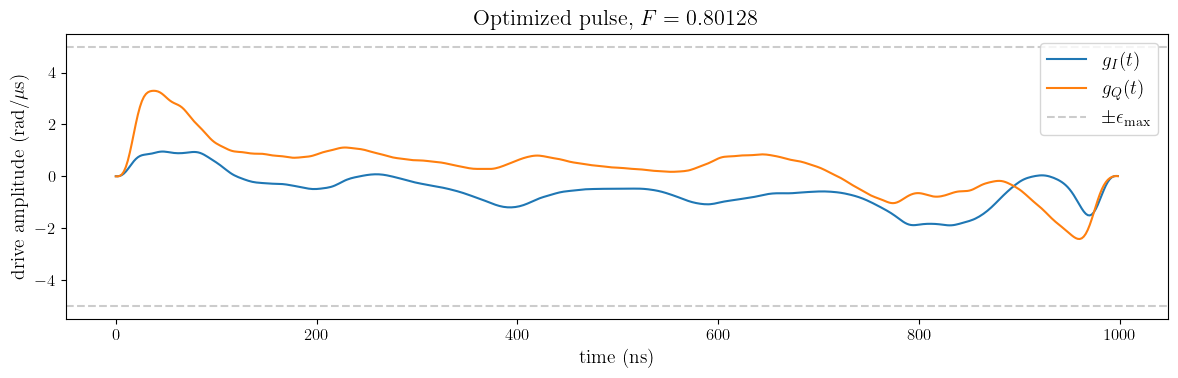

In [20]:
pulse = diag["pulse"]
times_ns = np.arange(time_grid.n_steps) * time_grid.dt * 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times_ns, pulse[0], label=r"$g_I(t)$")
ax.plot(times_ns, pulse[1], label=r"$g_Q(t)$")
ax.axhline(
    +penalties.eps_max, color="gray", linestyle="--", alpha=0.4, label=r"$\pm\epsilon_{\max}$"
)
ax.axhline(-penalties.eps_max, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("time (ns)")
ax.set_ylabel(r"drive amplitude (rad/$\mu$s)")
ax.set_title(rf"Optimized pulse, $F = {diag['F']:.5f}$")
ax.legend()
fig.tight_layout()
plt.show()

## Pulse spectrum

Frequency content of the optimized pulse. The hard cutoff at $f_{\max}$ is enforced by construction in the Fourier parametrization, not by a penalty.

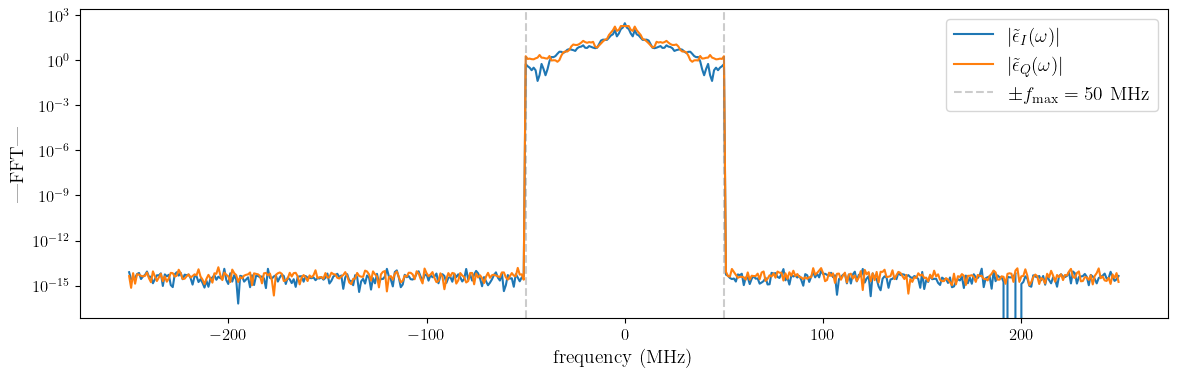

In [21]:
freqs = np.fft.fftshift(np.fft.fftfreq(time_grid.n_steps, d=time_grid.dt))
spectra = np.abs(np.fft.fftshift(np.fft.fft(pulse, axis=-1), axes=-1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs, spectra[0], label=r"$|\tilde\epsilon_I(\omega)|$")
ax.plot(freqs, spectra[1], label=r"$|\tilde\epsilon_Q(\omega)|$")
ax.axvline(
    +band.f_max,
    color="gray",
    linestyle="--",
    alpha=0.4,
    label=rf"$\pm f_{{\max}} = {band.f_max:g}$ MHz",
)
ax.axvline(-band.f_max, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("frequency (MHz)")
ax.set_ylabel("|FFT|")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()

## Final state vs. target

Wigner functions of the achieved final state and the target $\ket{0_L}$. A successful encoding reproduces the target's characteristic GKP lattice of positive and negative peaks.

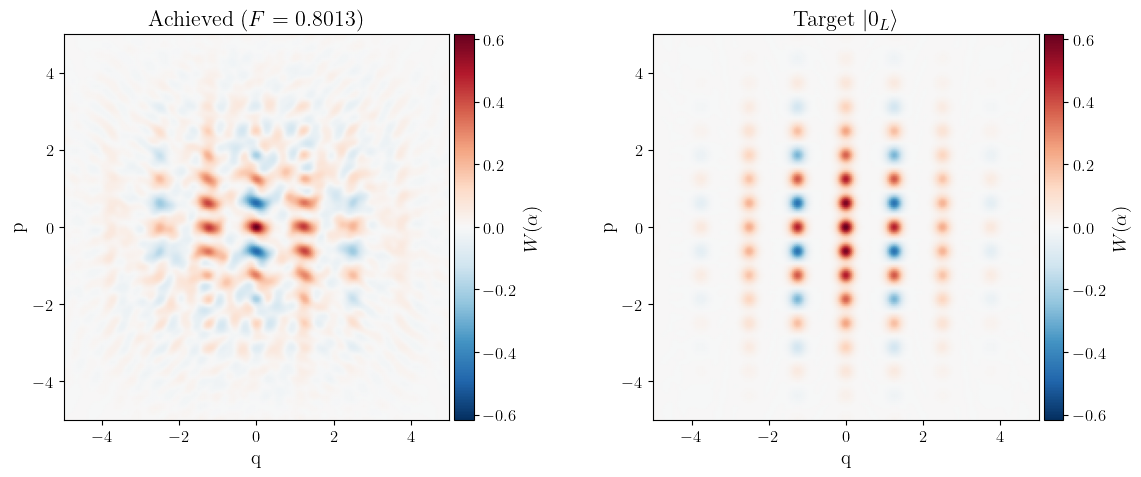

In [22]:
psi_final_qarr = jqt.Qarray.create(diag["psi_final"].reshape(n_fock, 1)).unit()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_wigner(
    psi_final_qarr, x_bound=5, y_bound=5, ax=axes[0], title=rf"Achieved ($F = {diag['F']:.4f}$)"
)
plot_wigner(gkp_0, x_bound=5, y_bound=5, ax=axes[1], title=r"Target $\ket{0_L}$")
fig.tight_layout()
plt.show()

## Photon-number distributions

Diagonal of the density matrix in the Fock basis. The achieved distribution should track the target. Significant population near $n = n_{\text{fock}}$ would indicate the truncation is too tight.

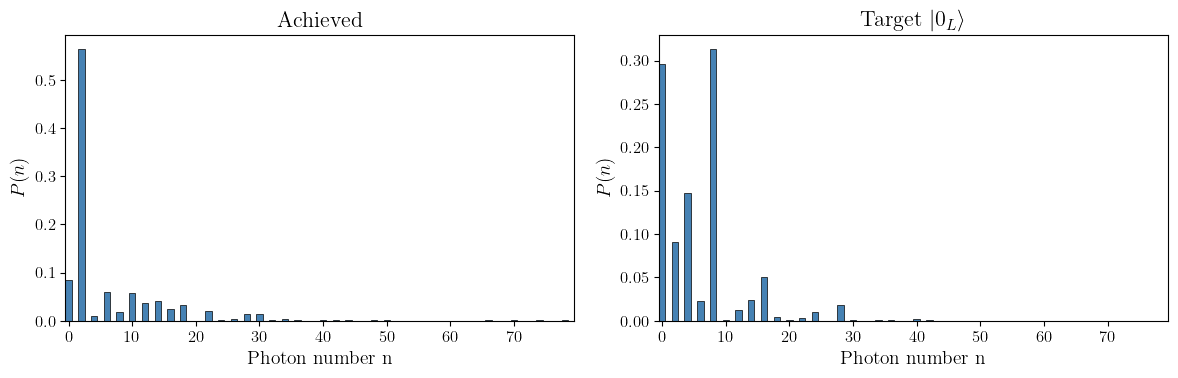

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_photon_number(psi_final_qarr, ax=axes[0], title="Achieved")
plot_photon_number(gkp_0, ax=axes[1], title=r"Target $\ket{0_L}$")
fig.tight_layout()
plt.show()

In [24]:
from IPython.display import HTML

frame_stride = 10  # capture every 10th step -> 50 frames for n_steps=500

pulse_jnp = jnp.asarray(diag["pulse"])
_, history = forward_evolve_history(
    pulse_jnp,
    time_grid.dt,
    system.psi_init,
    system.H_drift,
    system.H_controls,
)

# Subsample and wrap as a batched Qarray for jqt.wigner.
states_subsampled = np.asarray(history)[::frame_stride]  # (n_frames, dim)
states_qarr = jqt.Qarray.create(states_subsampled[..., None])  # (n_frames, dim, 1)

xvec, yvec, wigner_frames = wigner_trajectory(states_qarr, x_bound=5, y_bound=5, grid_points=120)

anim = animate_wigner(
    wigner_frames,
    xvec,
    yvec,
    title="Cavity Wigner during GKP encoding",
    save_path="../../vids/optimal_control/grape_encoding.mp4",  # or .gif
    fps=15,
    dpi=150,
)

## Save the pulse

Persist the optimized pulse along with the parameters needed to reconstruct it on hardware (or in a follow-up notebook).

In [ ]:
save_pulse(
    "pulse.npz",
    pulse,
    metadata={
        "fidelity": diag["F"],
        "T_us": time_grid.T,
        "n_steps": time_grid.n_steps,
        "f_max_MHz": band.f_max,
        "eps_max": penalties.eps_max,
        "n_fock": n_fock,
        "gkp_delta": gkp_delta,
        "K_rad_per_us": float(K),
    },
)